# Data Cleaning

Hey Ivette and Julia! As we discussed, I specifically loaded the bank-full.csv file and took the following steps for cleaning:


*   Checked for NA values (there were none to remove)
*   Converted all categorical variables to numeric
*   Defined X_bank_full and y_bank_full as features and target subsets of the bank_full dataframe

I figured for each algorithm I would let each of us do our own training and test set split, unless there's a good reason for us to use the same split. Let me know if I can answer any questions!

-Emmet

In [4]:
# From: https://archive.ics.uci.edu/dataset/222/bank+marketing
# pip install ucimlrepo

!pip install ucimlrepo

In [5]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# metadata
print(bank_marketing.metadata)

# variable information
print(bank_marketing.variables)

{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

In [6]:
import pandas as pd

In [7]:
bank_full = pd.read_csv('/content/drive/MyDrive/Coursework 2025 WIN/IMT 574/Assignments/bank+marketing/bank/bank-full.csv', sep = ';')
print(bank_full.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [8]:
# Identify unique labels in categorical columns
for column in list(bank_full.columns):
  unique_values= bank_full[str(column)].unique()
  print('Unique values in ' + str(column) + ':' + str(unique_values))

Unique values in age:[58 44 33 47 35 28 42 43 41 29 53 57 51 45 60 56 32 25 40 39 52 46 36 49
 59 37 50 54 55 48 24 38 31 30 27 34 23 26 61 22 21 20 66 62 83 75 67 70
 65 68 64 69 72 71 19 76 85 63 90 82 73 74 78 80 94 79 77 86 95 81 18 89
 84 87 92 93 88]
Unique values in job:['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
Unique values in marital:['married' 'single' 'divorced']
Unique values in education:['tertiary' 'secondary' 'unknown' 'primary']
Unique values in default:['no' 'yes']
Unique values in balance:[ 2143    29     2 ...  8205 14204 16353]
Unique values in housing:['yes' 'no']
Unique values in loan:['no' 'yes']
Unique values in contact:['unknown' 'cellular' 'telephone']
Unique values in day:[ 5  6  7  8  9 12 13 14 15 16 19 20 21 23 26 27 28 29 30  2  3  4 11 17
 18 24 25  1 10 22 31]
Unique values in month:['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr

In [9]:
# Convert categorical variables with integers
bank_full['job'].replace(['admin.', 'blue-collar', 'entrepreneur', 'housemaid',
                          'management', 'retired', 'self-employed', 'services',
                          'student', 'technician', 'unemployed', 'unknown'],
                           [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], inplace=True)
bank_full['marital'].replace(['single', 'married', 'divorced'],[1, 2, 3], inplace=True)
bank_full['education'].replace(['tertiary', 'secondary', 'unknown', 'primary'],[3, 2, 0, 1], inplace=True)
bank_full['default'].replace(['no', 'yes'], [0, 1], inplace=True)
bank_full['housing'].replace(['yes', 'no'], [1, 0], inplace=True)
bank_full['loan'].replace(['no', 'yes'], [0, 1], inplace=True)
bank_full['contact'].replace(['unknown', 'cellular', 'telephone'], [0, 1, 2], inplace=True)
bank_full['month'].replace(['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], inplace=True)
bank_full['poutcome'].replace(['unknown', 'failure', 'other', 'success'], [2, 0, 3, 1], inplace=True)
bank_full['y'].replace(['no', 'yes'], [0, 1], inplace=True)

<ipython-input-9-b8edec95c237>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bank_full['job'].replace(['admin.', 'blue-collar', 'entrepreneur', 'housemaid',
<ipython-input-9-b8edec95c237>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bank_full['job'].replace(['admin.', 'blue-collar', 'entrepre

In [10]:
# define features and targets dataframes
X_bank_full = bank_full[['age','job','marital','education','default','balance','housing','loan','contact','day','month','duration','campaign','pdays','previous','poutcome']]
y_bank_full = bank_full[['y']]

print(X_bank_full.head())
print(y_bank_full.head())

   age  job  marital  education  default  balance  housing  loan  contact  \
0   58    5        2          3        0     2143        1     0        0   
1   44   10        1          2        0       29        1     0        0   
2   33    3        2          2        0        2        1     1        0   
3   47    2        2          0        0     1506        1     0        0   
4   33   12        1          0        0        1        0     0        0   

   day  month  duration  campaign  pdays  previous  poutcome  
0    5      5       261         1     -1         0         2  
1    5      5       151         1     -1         0         2  
2    5      5        76         1     -1         0         2  
3    5      5        92         1     -1         0         2  
4    5      5       198         1     -1         0         2  
   y
0  0
1  0
2  0
3  0
4  0


# Random Forest Model

In [ ]:
# Steps for impementing random forest model
# - We have the dataset separated out into features and targets
# - Split into test set and training set
# - Decide which features to use or not -- could just use all of them??
# - Fit random forest model
# - Run predictions for random forest model
# - Calculate precision score for random forest model

In [ ]:
# Divide dataset into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_bank_full, y_bank_full, test_size=0.33, random_state=42, stratify=y)

# Try test size of 20%

# Note - I don't know if this is the best split; could try a different method e.g. k-fold, but I'm starting with this

In [ ]:
# Fit random forest model
from sklearn.ensemble import RandomForestClassifier
random_forest_model = RandomForestClassifier(n_estimators = 100, max_depth = 30, min_samples_split=15, criterion = 'gini')
random_forest_model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(max_depth=30, min_samples_split=15)

In [ ]:
# Run predictions for random forest model
y_pred_forest = random_forest_model.predict(X_test)
# print(y_pred_forest)

In [ ]:
# View classification ret
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_forest))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95     13175
           1       0.68      0.39      0.50      1745

    accuracy                           0.91     14920
   macro avg       0.80      0.68      0.72     14920
weighted avg       0.89      0.91      0.90     14920



/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


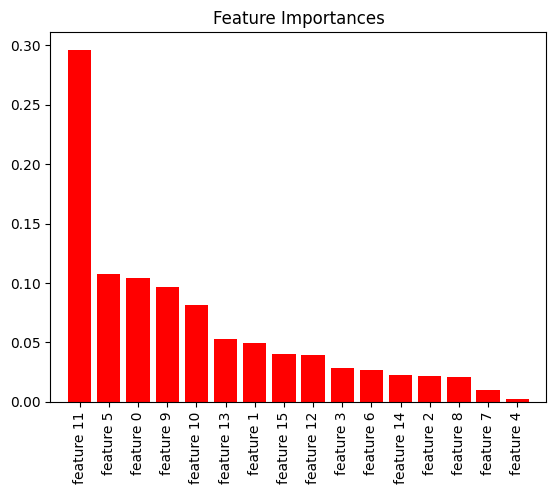

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier

feature_names = [f"feature {i}" for i in range(X_bank_full.shape[1])]
forest = RandomForestClassifier(random_state=0)
forest.fit(X_train, y_train)

# Feature Importance
importances = forest.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure()
plt.title("Feature Importances")
plt.bar(range(X_bank_full.shape[1]), importances[indices], color="r", align="center")
plt.xticks(range(X_bank_full.shape[1]), [feature_names[i] for i in indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.show()

In [ ]:
# Feature 11: Duration
# Feature 5: Balance
# Feature 0: Age
# Feature 9: Day of Week
# Feature 10: Month

In [ ]:
# variable information
print(bank_marketing.variables)

           name     role  ...  units missing_values
0           age  Feature  ...   None             no
1           job  Feature  ...   None             no
2       marital  Feature  ...   None             no
3     education  Feature  ...   None             no
4       default  Feature  ...   None             no
5       balance  Feature  ...  euros             no
6       housing  Feature  ...   None             no
7          loan  Feature  ...   None             no
8       contact  Feature  ...   None            yes
9   day_of_week  Feature  ...   None             no
10        month  Feature  ...   None             no
11     duration  Feature  ...   None             no
12     campaign  Feature  ...   None             no
13        pdays  Feature  ...   None            yes
14     previous  Feature  ...   None             no
15     poutcome  Feature  ...   None            yes
16            y   Target  ...   None             no

[17 rows x 7 columns]


# Random Forest with JUST Duration

In [ ]:
# define features and targets dataframes
X_bank_full_duration = bank_full[['duration']]
y_bank_full = bank_full[['y']]

In [ ]:
# Divide dataset into training and test sets
from sklearn.model_selection import train_test_split
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_bank_full_duration, y_bank_full, test_size=0.33, random_state=42, stratify=y)

# Note - I don't know if this is the best split; could try a different method e.g. k-fold, but I'm starting with this

In [ ]:
# Fit random forest model
rf_model_duration = RandomForestClassifier(n_estimators = 100, max_depth = 7, min_samples_split=15, criterion = 'gini')
rf_model_duration.fit(X_train_d, y_train_d)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(max_depth=30, min_samples_split=15)

In [ ]:
# Run predictions for random forest model
y_pred_forest_d = rf_model_duration.predict(X_test_d)
# print(y_pred_forest)

In [ ]:
# View classification ret
from sklearn.metrics import classification_report
print(classification_report(y_test_d, y_pred_forest_d))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94     13175
           1       0.48      0.17      0.25      1745

    accuracy                           0.88     14920
   macro avg       0.69      0.57      0.59     14920
weighted avg       0.85      0.88      0.86     14920



# Random Forest with 3 Most Important Features




In [ ]:
# define features and targets dataframes
X_bank_full_3f = bank_full[['duration','age','balance']]
y_bank_full = bank_full[['y']]

In [ ]:
# Divide dataset into training and test sets
from sklearn.model_selection import train_test_split
X_train_3f, X_test_3f, y_train_3f, y_test_3f = train_test_split(X_bank_full_3f, y_bank_full, test_size=0.33, random_state=42, stratify=y)

# Note - I don't know if this is the best split; could try a different method e.g. k-fold, but I'm starting with this

In [ ]:
# Fit random forest model
rf_model_3f = RandomForestClassifier(n_estimators = 100, max_depth = 30, min_samples_split=15, criterion = 'gini')
rf_model_3f.fit(X_train_3f, y_train_3f)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(max_depth=30, min_samples_split=15)

In [ ]:
# Run predictions for random forest model
y_pred_forest_3f = rf_model_3f.predict(X_test_3f)

In [ ]:
# view classification report
print(classification_report(y_test_3f, y_pred_forest_3f))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94     13175
           1       0.54      0.22      0.31      1745

    accuracy                           0.89     14920
   macro avg       0.72      0.60      0.62     14920
weighted avg       0.86      0.89      0.86     14920



# Random Forest with 5 Most Important Features

In [ ]:
# define features and targets dataframes
X_bank_full_5f = bank_full[['duration','age','balance', 'day', 'month']]
y_bank_full = bank_full[['y']]

In [ ]:
# split training and test data
X_train_5f, X_test_5f, y_train_5f, y_test_5f = train_test_split(X_bank_full_5f, y_bank_full, test_size=0.33, random_state=42, stratify=y)

In [ ]:
# Fit random forest model
rf_model_5f = RandomForestClassifier(n_estimators = 100, max_depth = 30, min_samples_split=15, criterion = 'gini')
rf_model_5f.fit(X_train_5f, y_train_5f)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(max_depth=30, min_samples_split=15)

In [ ]:
# Run predictions for random forest model
y_pred_forest_5f = rf_model_5f.predict(X_test_5f)

In [ ]:
# view classification report
print(classification_report(y_test_5f, y_pred_forest_5f))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94     13175
           1       0.59      0.34      0.43      1745

    accuracy                           0.89     14920
   macro avg       0.75      0.66      0.69     14920
weighted avg       0.88      0.89      0.88     14920



# Random Forest V6 - w/Grid Search Parameters and Adjusted Threshold

In [11]:
# Divide dataset into training and test sets -- adjusting to 20% test set
from sklearn.model_selection import train_test_split
X_train_V2, X_test_V2, y_train_V2, y_test_V2 = train_test_split(X_bank_full, y_bank_full, test_size=0.20, random_state=42, stratify=y)

In [15]:
# Fit random forest model
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators = 100, random_state=42)
rf_model.fit(X_train_V2, y_train_V2)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(random_state=42)

In [17]:
# Conduct grid search
from sklearn.model_selection import GridSearchCV
parameters = {'max_depth':list(range(1,30,2)), 'min_samples_split':list(range(2,30,2))}
rf_model_V2 = GridSearchCV(rf_model, param_grid=parameters, scoring='recall')
rf_model_V2.fit(X_train_V2, y_train_V2)
sorted(rf_model_V2.cv_results_.keys())

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

['mean_fit_time',
 'mean_score_time',
 'mean_test_score',
 'param_max_depth',
 'param_min_samples_split',
 'params',
 'rank_test_score',
 'split0_test_score',
 'split1_test_score',
 'split2_test_score',
 'split3_test_score',
 'split4_test_score',
 'std_fit_time',
 'std_score_time',
 'std_test_score']

In [18]:
# Convert gridsearch results to dataframe
rf_gridsearch_results = pd.DataFrame(rf_model_V2.cv_results_)

In [19]:
# Display gridsearch results
from IPython.display import display
import pandas as pd
display(rf_gridsearch_results)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.484822,0.341980,0.061287,0.027064,1,2,"{'max_depth': 1, 'min_samples_split': 2}",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,197
1,0.585695,0.069544,0.026477,0.004770,1,4,"{'max_depth': 1, 'min_samples_split': 4}",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,197
2,0.593077,0.066361,0.025147,0.004454,1,6,"{'max_depth': 1, 'min_samples_split': 6}",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,197
3,0.711598,0.230883,0.028548,0.006079,1,8,"{'max_depth': 1, 'min_samples_split': 8}",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,197
4,0.724869,0.113918,0.030465,0.006769,1,10,"{'max_depth': 1, 'min_samples_split': 10}",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,4.298326,0.523702,0.105955,0.001509,29,20,"{'max_depth': 29, 'min_samples_split': 20}",0.401891,0.374704,0.369540,0.411348,0.408983,0.393293,0.017640,78
206,4.227681,0.546479,0.125136,0.030685,29,22,"{'max_depth': 29, 'min_samples_split': 22}",0.401891,0.388889,0.378985,0.418440,0.416076,0.400856,0.015254,50
207,4.034761,0.298085,0.110663,0.010262,29,24,"{'max_depth': 29, 'min_samples_split': 24}",0.379433,0.371158,0.381346,0.425532,0.411348,0.393763,0.020924,76
208,4.210213,0.643634,0.114014,0.021016,29,26,"{'max_depth': 29, 'min_samples_split': 26}",0.386525,0.365248,0.371901,0.401891,0.416076,0.388328,0.018760,93


In [20]:
# Print gridsearch result with best mean recall score
print(rf_gridsearch_results.iloc[rf_gridsearch_results['rank_test_score'].idxmin()])

mean_fit_time                                               4.613804
std_fit_time                                                0.475958
mean_score_time                                             0.136572
std_score_time                                              0.021257
param_max_depth                                                   23
param_min_samples_split                                            2
params                     {'max_depth': 23, 'min_samples_split': 2}
split0_test_score                                           0.421986
split1_test_score                                           0.385343
split2_test_score                                           0.415584
split3_test_score                                           0.437352
split4_test_score                                           0.437352
mean_test_score                                             0.419524
std_test_score                                              0.019108
rank_test_score                   

In [22]:
# Fit updated random forest model
rf_model_V3 = RandomForestClassifier(random_state=42, max_depth=23, min_samples_split=2, criterion='gini')
rf_model_V3.fit(X_train_V2, y_train_V2)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(max_depth=23, random_state=42)

In [23]:
# Run predictions for Random Forest model with grid search parameters
y_pred_rf_V3 = rf_model_V3.predict(X_test_V2)

from sklearn.metrics import classification_report
print(classification_report(y_test_V2, y_pred_rf_V3))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7985
           1       0.65      0.41      0.50      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.69      0.72      9043
weighted avg       0.89      0.91      0.90      9043



In [28]:
# Set lower decision threshold
from sklearn.model_selection import FixedThresholdClassifier
rf_V3_lower_threshold = FixedThresholdClassifier(rf_model_V3, threshold=0.25, response_method="predict_proba").fit(X_train_V2, y_train_V2)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [29]:
# Run predictions for decision tree with lowered threshold
y_pred_rf_lthresh = rf_V3_lower_threshold.predict(X_test_V2)
print(classification_report(y_test_V2, y_pred_rf_lthresh))

              precision    recall  f1-score   support

           0       0.97      0.90      0.93      7985
           1       0.50      0.80      0.62      1058

    accuracy                           0.88      9043
   macro avg       0.74      0.85      0.77      9043
weighted avg       0.92      0.88      0.89      9043

